In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#part 1 - data scaling

df = pd.read_csv("q2_customers.csv")
df.head()
df.info()
df.describe()

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

# Convert back to DataFrame for readability
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)

df_scaled.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       500 non-null    int64
 1   annual_spend              500 non-null    int64
 2   visits_per_month          500 non-null    int64
 3   basket_size               500 non-null    int64
 4   days_since_last_visit     500 non-null    int64
 5   num_categories_purchased  500 non-null    int64
dtypes: int64(6)
memory usage: 23.6 KB


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


# Why scaling is essential before applying K-Means

K-Means clustering is a distance-based algorithm that relies on Euclidean distance to assign data points to clusters. If features are on different scales, variables with larger magnitudes (such as annual spend) will dominate the distance calculation, while smaller-scale features (such as visits per month) will have little influence.

Scaling ensures that all features contribute equally to the clustering process, leading to more meaningful and unbiased clusters.

In [ ]:
# part 2 Choosing K

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

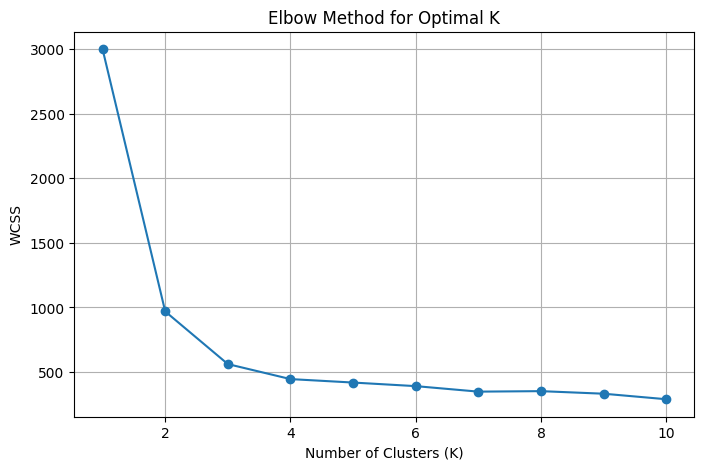

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True)
plt.show()

#Elbow Method Explanation

The Elbow Method helps determine the optimal number of clusters by plotting the Within-Cluster Sum of Squares (WCSS) against different values of K. As K increases, WCSS decreases because clusters become more compact.

However, beyond a certain point, the rate of decrease slows down significantly, forming an “elbow” in the graph. This point represents the optimal K, as adding more clusters does not significantly improve clustering performance.

Based on the plot, the optimal number of clusters is K = 3, where the elbow is observed.

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(df_scaled)

df['cluster'] = kmeans.labels_

df.head()

df['cluster'].value_counts()

,count
cluster,
0,170
2,165
1,165


In [ ]:
centroids = kmeans.cluster_centers_

# Convert back to original scale
centroids_original = scaler.inverse_transform(centroids)

centroids_df = pd.DataFrame(centroids_original, columns=df.columns[:-1])

centroids_df

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


#Cluster Interpretation:

Cluster 0: Represents customers with moderate age, high annual spending, and frequent visits. These are likely loyal and high-value customers.
Cluster 1: Consists of customers with lower spending, fewer visits, and longer gaps since their last visit. These may be disengaged or occasional customers.
Cluster 2: Includes customers with high basket size and diverse category purchases, indicating exploratory or variety-seeking behavior."

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_components = pca.fit_transform(df_scaled)


In [ ]:
pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])

# Add cluster labels for later use
pca_df['cluster'] = df['cluster']

pca_df.head()

,PC1,PC2,cluster
0,-0.333082,0.109379,2
1,-2.255362,0.048458,0
2,-0.092905,-0.679257,2
3,-2.017598,-0.308845,0
4,-2.917762,0.529368,0


In [ ]:
pca.explained_variance_ratio_

array([0.83560354, 0.05568764])

#Explained Variance Ratio:

The first principal component (PC1) explains 84% of the total variance, while the second principal component (PC2) explains 5%.

Together, they capture a significant portion of the dataset’s variability, making them suitable for visualization.

In [ ]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


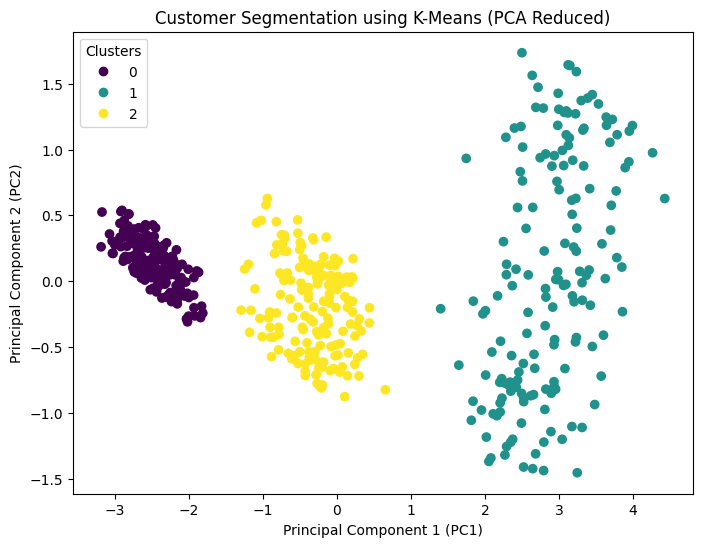

In [ ]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['cluster'],
    cmap='viridis'
)

plt.title("Customer Segmentation using K-Means (PCA Reduced)")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")

# Add legend
plt.legend(*scatter.legend_elements(), title="Clusters")

plt.show()

## 📝 Final Conclusion

 Customer segmentation was performed using K-Means clustering after scaling the data to ensure fair feature contribution. The Elbow Method identified **K = 3** as the optimal number of clusters.

 The resulting clusters revealed distinct customer groups based on spending behavior and engagement. PCA was used to reduce the data to two dimensions, capturing most of the variance and enabling clear visualization.

 The final plot showed well-separated clusters, indicating effective segmentation. This analysis can help businesses better understand customer behavior and design targeted strategies.
